In [2]:
import math
import matplotlib.pyplot as plt
import numpy as np

In [3]:
def linear_to_db(x):
    return 10 * math.log10(x)

def db_to_linear(x):
    return 10 ** (x / 10)

In [4]:
G_m_linear = db_to_linear(1)
G_rf_linear = db_to_linear(20)
D_if_linear = db_to_linear(30)
print(f"G_m_linear: {G_m_linear}, G_rf_linear: {G_rf_linear}, D_if_linear: {D_if_linear}")

G_m_linear: 1.2589254117941673, G_rf_linear: 100.0, D_if_linear: 1000.0


In [5]:
T_in = 20
T_rf = 45 
T_m = 450
T_if = 800
T_s = T_in + T_rf + (T_m / G_rf_linear) + (T_if / (G_m_linear * G_rf_linear))
print(f"T_s: {T_s}")

T_s: 75.85462587779425


In [ ]:
radius_earth_m = 6371e3 # meters
leo_satellite_altitude_m = 1000e3 # meters 
f_hz = 1.5e9  # Hz
c = 3e8 # m/s
keplers_constant = 3.896e14 # m^3/s^2

def satellite_v(altitude_m):
   return np.sqrt(keplers_constant / ((radius_earth_m + altitude_m))) # sqrt( m^3/s^2 / m ) = sqrt( m^2/s^2 ) = m/s

def doppler_f_khz(altitude_km, f_khz, elevation_angle_deg=20.07):
    altitude_m = altitude_km * 1e3  # m
    v = satellite_v(altitude_m) # m/s
    elevation_angle_rad = np.radians(elevation_angle_deg)
    return (v*radius_earth_m*f_khz*np.cos(elevation_angle_rad)) / (c*(radius_earth_m + altitude_m))  # (m/s * m * s^-1) / (m/s * m)) = (m^2/s^2) / (m^2/s) = 1/s = kHz

In [26]:
ku_band_khz = 15 * 1e6
k_band_khz = 22.5 * 1e6
ka_band_khz = 33.25 * 1e6

altitude_km = np.linspace(0, 40000, 4000)
doppler_f_shift_ku = doppler_f_khz(altitude_km, ku_band_khz)
doppler_f_shift_k = doppler_f_khz(altitude_km, k_band_khz)
doppler_f_shift_ka = doppler_f_khz(altitude_km, ka_band_khz)

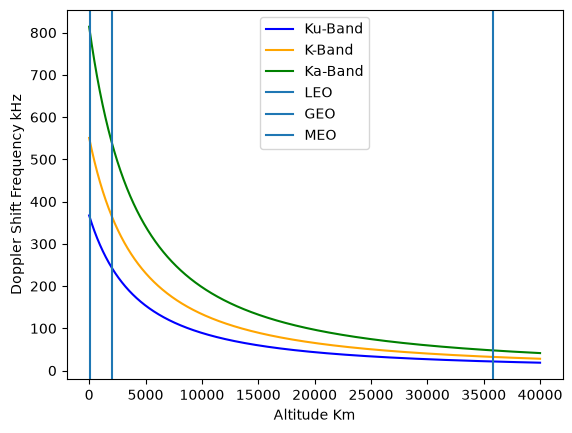

In [21]:
# Sanity check: recreating the plot from the article
plt.plot(altitude_km, doppler_f_shift_ku, label='Ku-Band', color='blue')
plt.plot(altitude_km, doppler_f_shift_k, label='K-Band', color='orange')
plt.plot(altitude_km, doppler_f_shift_ka, label='Ka-Band', color='green')
plt.axvline(x=106, label="LEO")
plt.axvline(x=35786, label="GEO")
plt.axvline(x=2000, label="MEO")

plt.xlabel('Altitude Km')
plt.ylabel('Doppler Shift Frequency kHz')
plt.legend()  # Displays the labels assigned above

In [29]:
angles = np.linspace(10, 170, (170-10)//5 + 1) # 10 to 170 in 5 degree increments

In [27]:
l_band = 1.5e6
altitude = 1000
doppler_f_shift = doppler_f_khz(altitude, l_band, angles)

Text(0.5, 1.0, 'Doppler Shift vs Angle for L-Band at 1000 km Altitude')

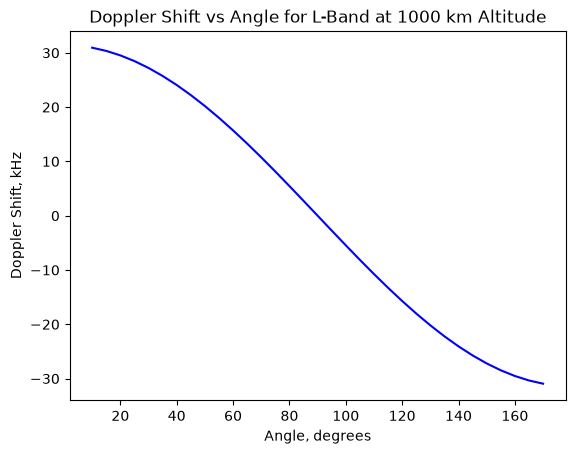

In [31]:
plt.plot(angles, doppler_f_shift,  color='blue')
plt.xlabel("Angle, degrees")
plt.ylabel("Doppler Shift, kHz")
plt.title("Doppler Shift vs Angle for L-Band at 1000 km Altitude")

In [ ]:
r_s = 20e6
alpha = .2
def b_occ(r_s, alpha):
    return r_s*(1 + alpha)
b_occ = b_occ(r_s, alpha)
print(f"b_occ: {b_occ} Hz or {b_occ/1e6} MHz")

def freq_range(r_s, alpha, f_c):
    return f_c - (r_s/2)*(1 + alpha), f_c + (r_s/2)*(1 + alpha)
lower, upper = freq_range(20e6, .2, 14e9)
print (f"Frequency range: {lower} Hz to {upper} Hz or {lower/1e9} GHz to {upper/1e9} GHz")